# 4. LightGBM - Gradient Boosting Leve e Rápido

## Descrição
LightGBM (Light Gradient Boosting Machine) é uma alternativa moderna ao XGBoost, conhecida pela eficiência computacional e performance competitiva. Utiliza crescimento de árvore leaf-wise em vez de level-wise.

## Características
- Gradient boosting otimizado
- Mais rápido que XGBoost
- Menor uso de memória
- Performance competitiva
- Alternativa moderna ao XGBoost

## Referências
- Ke, G., et al. (2017). LightGBM: A Fast, Distributed, High Performance Gradient Boosting Framework. In Advances in Neural Information Processing Systems (pp. 3146-3154).

## 1. Importações

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
from pathlib import Path

# Paths agnósticos
def get_project_root():
    path = Path.cwd()
    for _ in range(6):
        if (path / 'dados' / 'data_treino.csv').exists() or (path / 'data_treino.csv').exists(): return path
        if (path / 'dados' / 'processados').is_dir(): return path
        path = path.parent
    return Path.cwd()
PROJECT_ROOT = get_project_root()
DIR_DADOS_PROCESSADOS = PROJECT_ROOT / 'dados' / 'processados'
DIR_MODELOS = PROJECT_ROOT / 'modelos'
DIR_GRAFICOS = PROJECT_ROOT / 'graficos'

import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score, auc
)
import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

os.makedirs(DIR_GRAFICOS, exist_ok=True)
os.makedirs(DIR_MODELOS, exist_ok=True)

## 2. Carregamento dos Dados

In [8]:
with open(DIR_DADOS_PROCESSADOS / 'datasets.pkl', 'rb') as f:
    datasets = pickle.load(f)

X_train = datasets['baseline']['X_train']
X_val = datasets['baseline']['X_val']
X_test = datasets['baseline']['X_test']
y_train = datasets['baseline']['y_train']
y_val = datasets['baseline']['y_val']
y_test = datasets['baseline']['y_test']

print(f"Dados carregados: {X_train.shape}")

Dados carregados: (1730, 50)


## 3. Otimização de Hiperparâmetros

In [9]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 50, 100],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1],
    'min_child_samples': [5, 10, 20]
}

lgb_base = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)

random_search = RandomizedSearchCV(
    lgb_base,
    param_dist,
    n_iter=50,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Treinando LightGBM...")
random_search.fit(X_train, y_train)

print(f"\nMelhores parâmetros encontrados")
print(f"Melhor F1-score: {random_search.best_score_:.4f}")

Treinando LightGBM...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Melhores parâmetros encontrados
Melhor F1-score: 0.6961


## 4. Avaliação

In [10]:
lgb_model = random_search.best_estimator_

y_test_pred = lgb_model.predict(X_test)
y_test_pred_proba = lgb_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_pred_proba)
test_pr_auc = auc(recall_vals, precision_vals)

print("="*60)
print("MÉTRICAS - LightGBM")
print("="*60)
print(f"F1-Score: {test_f1:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print(f"Acurácia: {test_accuracy:.4f}")
print(f"Precisão: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"PR-AUC: {test_pr_auc:.4f}")
print("="*60)

MÉTRICAS - LightGBM
F1-Score: 0.6887
ROC-AUC: 0.6703
Acurácia: 0.5941
Precisão: 0.5964
Recall: 0.8146
PR-AUC: 0.6967


## 5. Visualizações

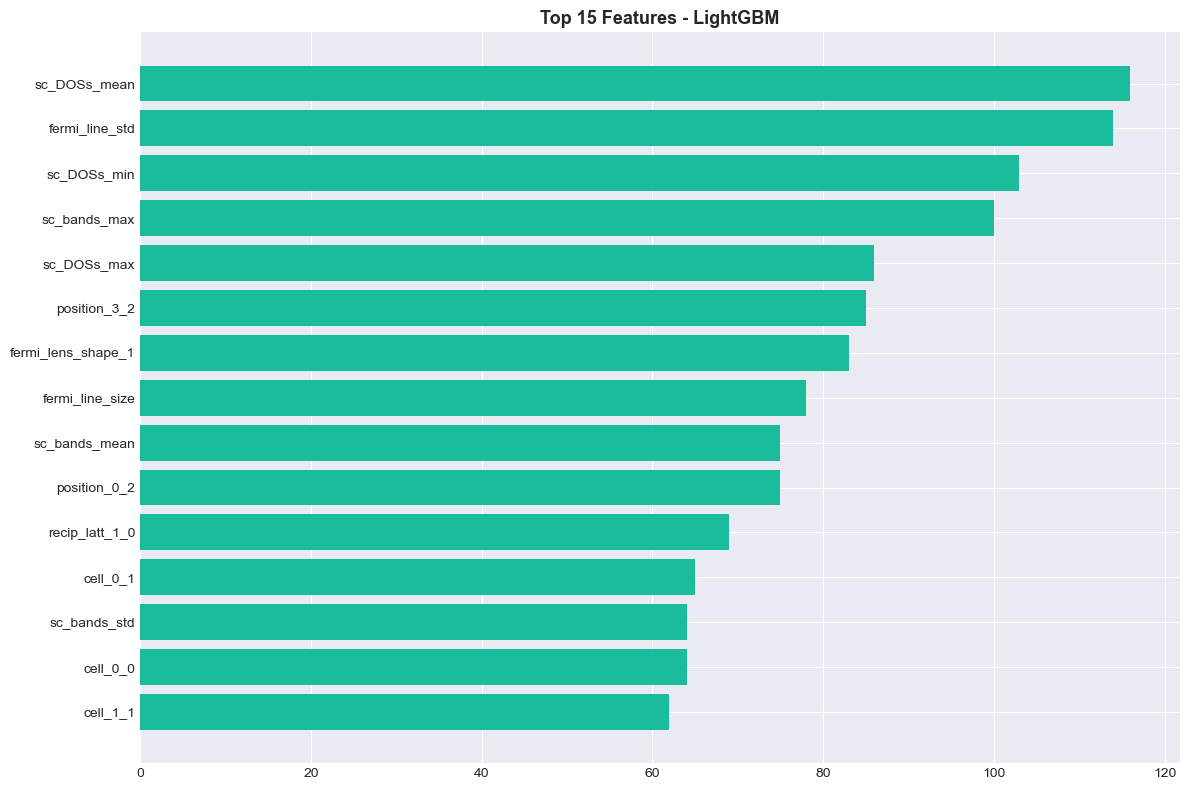

In [11]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
top_features = feature_importance.head(15)
ax.barh(range(len(top_features)), top_features['importance'].values, color='#1ABC9C')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_title('Top 15 Features - LightGBM', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(DIR_GRAFICOS / '04_lgb_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Salvamento

In [12]:
joblib.dump(lgb_model, DIR_MODELOS / 'lightgbm_model.pkl')

results = {
    'model_name': 'LightGBM',
    'best_params': random_search.best_params_,
    'metrics': {
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc,
        'test_pr_auc': test_pr_auc
    },
    'feature_importance': feature_importance,
    'predictions': {
        'y_test_pred': y_test_pred,
        'y_test_pred_proba': y_test_pred_proba
    }
}

with open(DIR_MODELOS / 'lightgbm_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("Modelo LightGBM salvo com sucesso!")

Modelo LightGBM salvo com sucesso!
